In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [2]:
df=pd.read_csv('Used_Car_50k.csv')
df

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti wagon r,2007.965992,petrol,37047.347056,1.090945e+05,new delhi,10527.979656,hatchback,manual,lxi,...,0.995750,9.876549e+04,NaN,great,2021-02-02T10:06:15.422,True,2515.757339,16957.752832,True,False
1,maruti alto k10,2010.983001,petrol,80430.370425,2.580151e+05,chennai,374.907850,hatchback,manual,lxi,...,0.998296,2.166066e+05,2.590545e+05,good,2021-03-18T11:05:00.728,True,5885.909121,38560.428826,False,False
2,ford ecosport,2017.929802,diesel,5170.612874,9.483337e+05,new delhi,436.373962,NaN,NaN,1.5 tdci titanium plus,...,1.001294,6.781848e+05,NaN,great,2020-05-30T14:40:40.184,True,22079.222766,142554.115844,False,False
3,mahindra xuv500,2014.994807,diesel,82304.131491,9.459613e+05,mumbai,1251.603618,luxury suv,manual,w10,...,0.999524,9.245775e+05,NaN,great,2021-03-30T11:00:49.298,True,21914.093816,141978.306136,False,False
4,audi a6,2012.039742,diesel,91314.820341,1.051463e+06,ghaziabad,2717.175522,luxury sedan,automatic,2.0 tdi premium plus,...,2.004161,1.081066e+06,1.301035e+06,great,2020-10-16T11:10:02.968,True,24290.548407,157489.699985,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,honda jazz,2016.024994,petrol,32351.859546,5.795143e+05,pune,1938.131285,hatchback,automatic,1.2 v at,...,0.990936,5.976321e+05,5.905758e+05,great,2021-02-26T13:33:43.952,True,13466.686556,87477.194889,False,False
49996,tata nano,2015.974442,petrol,12818.128818,1.955879e+05,bengaluru,2486.416738,hatchback,manual,xt twist,...,0.995204,1.931459e+05,NaN,great,2021-02-23T13:13:57.478,True,4667.534538,29735.024034,False,False
49997,hyundai i20,2011.985577,diesel,77337.477188,2.759535e+05,ghaziabad,1101.631298,hatchback,manual,magna o 1.4 crdi,...,0.997773,2.574209e+05,3.365338e+05,great,2021-02-20T09:25:17.225,True,6468.862726,41405.828381,True,False
49998,honda brio,2012.992009,petrol,45627.982766,2.772799e+05,gurgaon,2053.194216,hatchback,manual,1.2 s mt i vtec,...,1.002408,2.556030e+05,NaN,great,2021-04-19T08:47:52.161,True,6450.594577,42061.173338,False,False


In [3]:
df.shape

(50000, 29)

In [4]:
df.head()

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti wagon r,2007.965992,petrol,37047.347056,1.090945e+05,new delhi,10527.979656,hatchback,manual,lxi,...,0.995750,9.876549e+04,NaN,great,2021-02-02T10:06:15.422,True,2515.757339,16957.752832,True,False
1,maruti alto k10,2010.983001,petrol,80430.370425,2.580151e+05,chennai,374.907850,hatchback,manual,lxi,...,0.998296,2.166066e+05,2.590545e+05,good,2021-03-18T11:05:00.728,True,5885.909121,38560.428826,False,False
2,ford ecosport,2017.929802,diesel,5170.612874,9.483337e+05,new delhi,436.373962,NaN,NaN,1.5 tdci titanium plus,...,1.001294,6.781848e+05,NaN,great,2020-05-30T14:40:40.184,True,22079.222766,142554.115844,False,False
3,mahindra xuv500,2014.994807,diesel,82304.131491,9.459613e+05,mumbai,1251.603618,luxury suv,manual,w10,...,0.999524,9.245775e+05,NaN,great,2021-03-30T11:00:49.298,True,21914.093816,141978.306136,False,False
4,audi a6,2012.039742,diesel,91314.820341,1.051463e+06,ghaziabad,2717.175522,luxury sedan,automatic,2.0 tdi premium plus,...,2.004161,1.081066e+06,1.301035e+06,great,2020-10-16T11:10:02.968,True,24290.548407,157489.699985,False,False


In [5]:
df.tail()

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
49995,honda jazz,2016.024994,petrol,32351.859546,579514.320626,pune,1938.131285,hatchback,automatic,1.2 v at,...,0.990936,597632.128714,590575.837465,great,2021-02-26T13:33:43.952,True,13466.686556,87477.194889,False,False
49996,tata nano,2015.974442,petrol,12818.128818,195587.854941,bengaluru,2486.416738,hatchback,manual,xt twist,...,0.995204,193145.853152,NaN,great,2021-02-23T13:13:57.478,True,4667.534538,29735.024034,False,False
49997,hyundai i20,2011.985577,diesel,77337.477188,275953.476899,ghaziabad,1101.631298,hatchback,manual,magna o 1.4 crdi,...,0.997773,257420.871055,336533.751029,great,2021-02-20T09:25:17.225,True,6468.862726,41405.828381,True,False
49998,honda brio,2012.992009,petrol,45627.982766,277279.863864,gurgaon,2053.194216,hatchback,manual,1.2 s mt i vtec,...,1.002408,255602.967011,NaN,great,2021-04-19T08:47:52.161,True,6450.594577,42061.173338,False,False
49999,volkswagen ameo,2016.026214,petrol,43267.829260,518809.304743,hyderabad,2053.654911,sedan,manual,highline 1.2,...,2.003930,492151.930646,593475.546543,great,2021-03-10T08:30:17.144,True,11941.714546,77063.556817,False,False


In [6]:
df.columns

Index(['car_name', 'yr_mfr', 'fuel_type', 'kms_run', 'sale_price', 'city',
       'times_viewed', 'body_type', 'transmission', 'variant', 'assured_buy',
       'registered_city', 'registered_state', 'is_hot', 'rto', 'source',
       'make', 'model', 'car_availability', 'total_owners', 'broker_quote',
       'original_price', 'car_rating', 'ad_created_on', 'fitness_certificate',
       'emi_starts_from', 'booking_down_pymnt', 'reserved', 'warranty_avail'],
      dtype='str')

In [7]:
df['fuel_type'].unique()

<ArrowStringArray>
['petrol', 'diesel', 'petrol & cng', 'electric', 'petrol & lpg']
Length: 5, dtype: str

In [8]:
df['fuel_type'].value_counts()

fuel_type
petrol          31430
diesel          15258
petrol & cng     2993
petrol & lpg      274
electric           45
Name: count, dtype: int64

In [9]:
df.info

<bound method DataFrame.info of               car_name       yr_mfr fuel_type       kms_run    sale_price  \
0       maruti wagon r  2007.965992    petrol  37047.347056  1.090945e+05   
1      maruti alto k10  2010.983001    petrol  80430.370425  2.580151e+05   
2        ford ecosport  2017.929802    diesel   5170.612874  9.483337e+05   
3      mahindra xuv500  2014.994807    diesel  82304.131491  9.459613e+05   
4              audi a6  2012.039742    diesel  91314.820341  1.051463e+06   
...                ...          ...       ...           ...           ...   
49995       honda jazz  2016.024994    petrol  32351.859546  5.795143e+05   
49996        tata nano  2015.974442    petrol  12818.128818  1.955879e+05   
49997      hyundai i20  2011.985577    diesel  77337.477188  2.759535e+05   
49998       honda brio  2012.992009    petrol  45627.982766  2.772799e+05   
49999  volkswagen ameo  2016.026214    petrol  43267.829260  5.188093e+05   

            city  times_viewed     body_typ

In [10]:
df.dtypes

car_name                   str
yr_mfr                 float64
fuel_type                  str
kms_run                float64
sale_price             float64
city                       str
times_viewed           float64
body_type                  str
transmission               str
variant                    str
assured_buy               bool
registered_city            str
registered_state           str
is_hot                    bool
rto                        str
source                     str
make                       str
model                      str
car_availability           str
total_owners           float64
broker_quote           float64
original_price         float64
car_rating                 str
ad_created_on              str
fitness_certificate     object
emi_starts_from        float64
booking_down_pymnt     float64
reserved                  bool
warranty_avail            bool
dtype: object

In [11]:
df.describe()

,yr_mfr,kms_run,sale_price,times_viewed,total_owners,broker_quote,original_price,emi_starts_from,booking_down_pymnt
count,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,5.000000e+04,2.792400e+04,50000.000000,50000.000000
mean,2013.896709,62485.165229,4.557188e+05,1534.128815,1.327123,4.330664e+05,5.511182e+05,10585.515916,68359.127881
std,3.103424,43165.027571,2.855854e+05,1889.057293,0.579815,2.900100e+05,3.133170e+05,6633.810453,42839.775799
min,1995.952445,0.000000,0.000000e+00,0.000000,0.975849,0.000000e+00,9.388607e+04,0.000000,0.000000
25%,2011.972851,32057.024744,2.808152e+05,551.012047,0.997700,2.524450e+05,3.385439e+05,6514.232251,42107.437219
50%,2014.001578,55533.038775,3.829711e+05,1083.730775,1.002862,3.611422e+05,4.678297e+05,8892.779726,57420.573986
75%,2016.022081,84030.712591,5.418624e+05,1931.582725,1.992907,5.279245e+05,6.706029e+05,12594.886491,81263.009784
max,2021.046451,997220.523552,3.869074e+06,61942.907257,6.011686,3.254147e+06,2.771172e+06,89875.650318,580790.057913


In [12]:
df.isna().sum()

car_name                   0
yr_mfr                     0
fuel_type                  0
kms_run                    0
sale_price                 0
city                       0
times_viewed               0
body_type                678
transmission            3776
variant                    0
assured_buy                0
registered_city           59
registered_state          59
is_hot                     0
rto                        0
source                   791
make                       0
model                      0
car_availability        4255
total_owners               0
broker_quote               0
original_price         22076
car_rating                53
ad_created_on              3
fitness_certificate       46
emi_starts_from            0
booking_down_pymnt         0
reserved                   0
warranty_avail             0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop( ['car_name',
    'variant',
    'registered_city',
    'registered_state',
    'rto',
    'source',
    'car_availability',
    'broker_quote',
    'fitness_certificate',
    'reserved'],axis=1,inplace=True)

In [15]:
df.columns

Index(['yr_mfr', 'fuel_type', 'kms_run', 'sale_price', 'city', 'times_viewed',
       'body_type', 'transmission', 'assured_buy', 'is_hot', 'make', 'model',
       'total_owners', 'original_price', 'car_rating', 'ad_created_on',
       'emi_starts_from', 'booking_down_pymnt', 'warranty_avail'],
      dtype='str')

In [16]:
df

,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,assured_buy,is_hot,make,model,total_owners,original_price,car_rating,ad_created_on,emi_starts_from,booking_down_pymnt,warranty_avail
0,2007.965992,petrol,37047.347056,1.090945e+05,new delhi,10527.979656,hatchback,manual,True,True,maruti,wagon r,0.995750,NaN,great,2021-02-02T10:06:15.422,2515.757339,16957.752832,False
1,2010.983001,petrol,80430.370425,2.580151e+05,chennai,374.907850,hatchback,manual,True,True,maruti,alto k10,0.998296,2.590545e+05,good,2021-03-18T11:05:00.728,5885.909121,38560.428826,False
2,2017.929802,diesel,5170.612874,9.483337e+05,new delhi,436.373962,NaN,NaN,False,False,ford,ecosport,1.001294,NaN,great,2020-05-30T14:40:40.184,22079.222766,142554.115844,False
3,2014.994807,diesel,82304.131491,9.459613e+05,mumbai,1251.603618,luxury suv,manual,True,True,mahindra,xuv500,0.999524,NaN,great,2021-03-30T11:00:49.298,21914.093816,141978.306136,False
4,2012.039742,diesel,91314.820341,1.051463e+06,ghaziabad,2717.175522,luxury sedan,automatic,True,True,audi,a6,2.004161,1.301035e+06,great,2020-10-16T11:10:02.968,24290.548407,157489.699985,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2016.024994,petrol,32351.859546,5.795143e+05,pune,1938.131285,hatchback,automatic,True,True,honda,jazz,0.990936,5.905758e+05,great,2021-02-26T13:33:43.952,13466.686556,87477.194889,False
49996,2015.974442,petrol,12818.128818,1.955879e+05,bengaluru,2486.416738,hatchback,manual,True,True,tata,nano,0.995204,NaN,great,2021-02-23T13:13:57.478,4667.534538,29735.024034,False
49997,2011.985577,diesel,77337.477188,2.759535e+05,ghaziabad,1101.631298,hatchback,manual,True,True,hyundai,i20,0.997773,3.365338e+05,great,2021-02-20T09:25:17.225,6468.862726,41405.828381,False
49998,2012.992009,petrol,45627.982766,2.772799e+05,gurgaon,2053.194216,hatchback,manual,True,True,honda,brio,1.002408,NaN,great,2021-04-19T08:47:52.161,6450.594577,42061.173338,False


In [17]:
df.corr(numeric_only=True)

,yr_mfr,kms_run,sale_price,times_viewed,assured_buy,is_hot,total_owners,original_price,emi_starts_from,booking_down_pymnt,warranty_avail
yr_mfr,1.000000,-0.401229,0.517842,0.074150,0.119147,0.197913,-0.305684,0.513472,0.517866,0.517933,-0.006415
kms_run,-0.401229,1.000000,-0.111715,-0.127613,-0.020496,-0.111723,0.139426,-0.087263,-0.111786,-0.111795,0.017497
sale_price,0.517842,-0.111715,1.000000,0.092242,0.017712,0.053479,-0.136337,0.985980,0.999900,0.999900,-0.017630
times_viewed,0.074150,-0.127613,0.092242,1.000000,0.079451,0.190512,0.001082,0.101940,0.092301,0.092203,-0.044975
assured_buy,0.119147,-0.020496,0.017712,0.079451,1.000000,0.375575,-0.074788,0.006403,0.017754,0.017722,-0.018991
is_hot,0.197913,-0.111723,0.053479,0.190512,0.375575,1.000000,-0.135782,0.008336,0.053425,0.053476,-0.334870
total_owners,-0.305684,0.139426,-0.136337,0.001082,-0.074788,-0.135782,1.000000,-0.088710,-0.136415,-0.136426,0.017661
original_price,0.513472,-0.087263,0.985980,0.101940,0.006403,0.008336,-0.088710,1.000000,0.985976,0.985980,-0.005496
emi_starts_from,0.517866,-0.111786,0.999900,0.092301,0.017754,0.053425,-0.136415,0.985976,1.000000,0.999900,-0.017585
booking_down_pymnt,0.517933,-0.111795,0.999900,0.092203,0.017722,0.053476,-0.136426,0.985980,0.999900,1.000000,-0.017684


In [18]:
df.isna().sum()

yr_mfr                    0
fuel_type                 0
kms_run                   0
sale_price                0
city                      0
times_viewed              0
body_type               678
transmission           3776
assured_buy               0
is_hot                    0
make                      0
model                     0
total_owners              0
original_price        22076
car_rating               53
ad_created_on             3
emi_starts_from           0
booking_down_pymnt        0
warranty_avail            0
dtype: int64

In [19]:
df.dtypes

yr_mfr                float64
fuel_type                 str
kms_run               float64
sale_price            float64
city                      str
times_viewed          float64
body_type                 str
transmission              str
assured_buy              bool
is_hot                   bool
make                      str
model                     str
total_owners          float64
original_price        float64
car_rating                str
ad_created_on             str
emi_starts_from       float64
booking_down_pymnt    float64
warranty_avail           bool
dtype: object

In [20]:
df['transmission']=df['transmission'].fillna(df['transmission'].mode()[0],inplace=True)
df['body_type']=df['body_type'].fillna(df['body_type'].mode()[0],inplace=True)
df['car_rating']=df['car_rating'].fillna(df['car_rating'].mode()[0],inplace=True)
df['original_price'] = df['original_price'].fillna(df['original_price'].mode()[0])

In [21]:
df=df.dropna(subset=['ad_created_on'])

In [22]:
df.isna().sum()

yr_mfr                0
fuel_type             0
kms_run               0
sale_price            0
city                  0
times_viewed          0
body_type             0
transmission          0
assured_buy           0
is_hot                0
make                  0
model                 0
total_owners          0
original_price        0
car_rating            0
ad_created_on         0
emi_starts_from       0
booking_down_pymnt    0
warranty_avail        0
dtype: int64

In [23]:
df['ad_created_on'].head()

0    2021-02-02T10:06:15.422
1    2021-03-18T11:05:00.728
2    2020-05-30T14:40:40.184
3    2021-03-30T11:00:49.298
4    2020-10-16T11:10:02.968
Name: ad_created_on, dtype: str

In [24]:
df['ad_created_on'] = pd.to_datetime(df['ad_created_on'], errors='coerce')

In [25]:
df['year'] = df['ad_created_on'].dt.year
df['month'] = df['ad_created_on'].dt.month

In [26]:
df

,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,assured_buy,is_hot,...,model,total_owners,original_price,car_rating,ad_created_on,emi_starts_from,booking_down_pymnt,warranty_avail,year,month
0,2007.965992,petrol,37047.347056,1.090945e+05,new delhi,10527.979656,hatchback,manual,True,True,...,wagon r,0.995750,9.388607e+04,great,2021-02-02 10:06:15.422,2515.757339,16957.752832,False,2021.0,2.0
1,2010.983001,petrol,80430.370425,2.580151e+05,chennai,374.907850,hatchback,manual,True,True,...,alto k10,0.998296,2.590545e+05,good,2021-03-18 11:05:00.728,5885.909121,38560.428826,False,2021.0,3.0
2,2017.929802,diesel,5170.612874,9.483337e+05,new delhi,436.373962,hatchback,manual,False,False,...,ecosport,1.001294,9.388607e+04,great,2020-05-30 14:40:40.184,22079.222766,142554.115844,False,2020.0,5.0
3,2014.994807,diesel,82304.131491,9.459613e+05,mumbai,1251.603618,luxury suv,manual,True,True,...,xuv500,0.999524,9.388607e+04,great,2021-03-30 11:00:49.298,21914.093816,141978.306136,False,2021.0,3.0
4,2012.039742,diesel,91314.820341,1.051463e+06,ghaziabad,2717.175522,luxury sedan,automatic,True,True,...,a6,2.004161,1.301035e+06,great,2020-10-16 11:10:02.968,24290.548407,157489.699985,False,2020.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2016.024994,petrol,32351.859546,5.795143e+05,pune,1938.131285,hatchback,automatic,True,True,...,jazz,0.990936,5.905758e+05,great,2021-02-26 13:33:43.952,13466.686556,87477.194889,False,2021.0,2.0
49996,2015.974442,petrol,12818.128818,1.955879e+05,bengaluru,2486.416738,hatchback,manual,True,True,...,nano,0.995204,9.388607e+04,great,2021-02-23 13:13:57.478,4667.534538,29735.024034,False,2021.0,2.0
49997,2011.985577,diesel,77337.477188,2.759535e+05,ghaziabad,1101.631298,hatchback,manual,True,True,...,i20,0.997773,3.365338e+05,great,2021-02-20 09:25:17.225,6468.862726,41405.828381,False,2021.0,2.0
49998,2012.992009,petrol,45627.982766,2.772799e+05,gurgaon,2053.194216,hatchback,manual,True,True,...,brio,1.002408,9.388607e+04,great,2021-04-19 08:47:52.161,6450.594577,42061.173338,False,2021.0,4.0


In [27]:
df=df.drop('ad_created_on',axis=1)

In [28]:
df.isna().sum()

yr_mfr                 0
fuel_type              0
kms_run                0
sale_price             0
city                   0
times_viewed           0
body_type              0
transmission           0
assured_buy            0
is_hot                 0
make                   0
model                  0
total_owners           0
original_price         0
car_rating             0
emi_starts_from        0
booking_down_pymnt     0
warranty_avail         0
year                  30
month                 30
dtype: int64

In [29]:
df['year']=df['year'].fillna(df['year'].median())
df['month']=df['month'].fillna(df['month'].mode()[0])

In [30]:
df.isna().sum()

yr_mfr                0
fuel_type             0
kms_run               0
sale_price            0
city                  0
times_viewed          0
body_type             0
transmission          0
assured_buy           0
is_hot                0
make                  0
model                 0
total_owners          0
original_price        0
car_rating            0
emi_starts_from       0
booking_down_pymnt    0
warranty_avail        0
year                  0
month                 0
dtype: int64

In [31]:
df

,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,assured_buy,is_hot,make,model,total_owners,original_price,car_rating,emi_starts_from,booking_down_pymnt,warranty_avail,year,month
0,2007.965992,petrol,37047.347056,1.090945e+05,new delhi,10527.979656,hatchback,manual,True,True,maruti,wagon r,0.995750,9.388607e+04,great,2515.757339,16957.752832,False,2021.0,2.0
1,2010.983001,petrol,80430.370425,2.580151e+05,chennai,374.907850,hatchback,manual,True,True,maruti,alto k10,0.998296,2.590545e+05,good,5885.909121,38560.428826,False,2021.0,3.0
2,2017.929802,diesel,5170.612874,9.483337e+05,new delhi,436.373962,hatchback,manual,False,False,ford,ecosport,1.001294,9.388607e+04,great,22079.222766,142554.115844,False,2020.0,5.0
3,2014.994807,diesel,82304.131491,9.459613e+05,mumbai,1251.603618,luxury suv,manual,True,True,mahindra,xuv500,0.999524,9.388607e+04,great,21914.093816,141978.306136,False,2021.0,3.0
4,2012.039742,diesel,91314.820341,1.051463e+06,ghaziabad,2717.175522,luxury sedan,automatic,True,True,audi,a6,2.004161,1.301035e+06,great,24290.548407,157489.699985,False,2020.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2016.024994,petrol,32351.859546,5.795143e+05,pune,1938.131285,hatchback,automatic,True,True,honda,jazz,0.990936,5.905758e+05,great,13466.686556,87477.194889,False,2021.0,2.0
49996,2015.974442,petrol,12818.128818,1.955879e+05,bengaluru,2486.416738,hatchback,manual,True,True,tata,nano,0.995204,9.388607e+04,great,4667.534538,29735.024034,False,2021.0,2.0
49997,2011.985577,diesel,77337.477188,2.759535e+05,ghaziabad,1101.631298,hatchback,manual,True,True,hyundai,i20,0.997773,3.365338e+05,great,6468.862726,41405.828381,False,2021.0,2.0
49998,2012.992009,petrol,45627.982766,2.772799e+05,gurgaon,2053.194216,hatchback,manual,True,True,honda,brio,1.002408,9.388607e+04,great,6450.594577,42061.173338,False,2021.0,4.0


In [32]:
df['sale_price'].describe()

count    4.999700e+04
mean     4.557101e+05
std      2.855918e+05
min      0.000000e+00
25%      2.808038e+05
50%      3.829667e+05
75%      5.418134e+05
max      3.869074e+06
Name: sale_price, dtype: float64

In [33]:
df = df[df['sale_price'] > 0]

In [34]:
df['sale_price'].describe()

count    4.997700e+04
mean     4.558925e+05
std      2.855034e+05
min      2.186176e+02
25%      2.809305e+05
50%      3.831527e+05
75%      5.419090e+05
max      3.869074e+06
Name: sale_price, dtype: float64

In [35]:
hist_cols = [
    'sale_price',
    'kms_run',
    'times_viewed',
    'total_owners',
    'car_rating',
    'emi_starts_from',
    'booking_down_pymnt',
    'year',
    'month'
]

<Axes: xlabel='sale_price', ylabel='Count'>

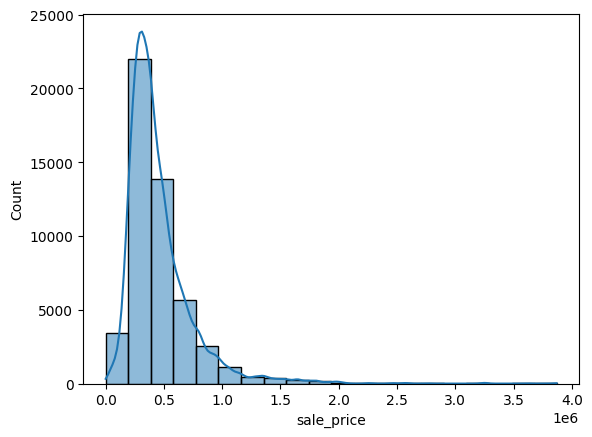

In [36]:
sns.histplot(df['sale_price'],kde=True,bins = 20)

<Axes: xlabel='kms_run', ylabel='Count'>

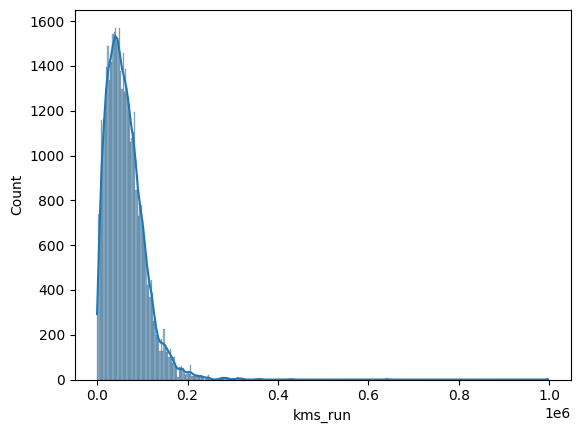

In [37]:
sns.histplot(df['kms_run'],kde=True)

<Axes: xlabel='times_viewed', ylabel='Count'>

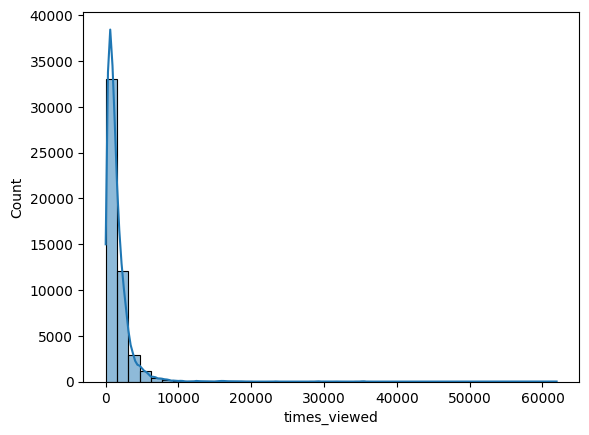

In [38]:
sns.histplot(df['times_viewed'],kde=True,bins = 40)

<Axes: xlabel='total_owners', ylabel='Count'>

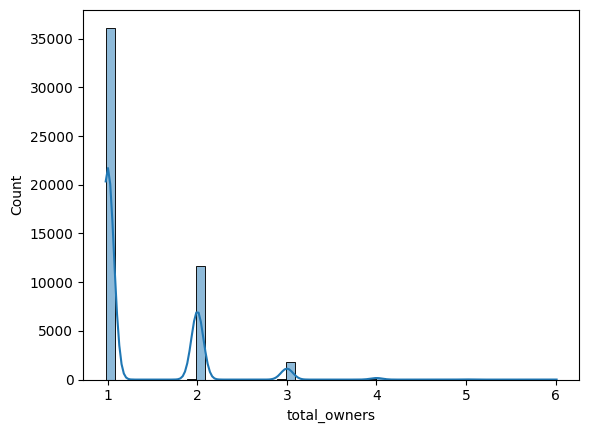

In [39]:
sns.histplot(df['total_owners'],kde=True,bins=50)

<Axes: xlabel='car_rating', ylabel='Count'>

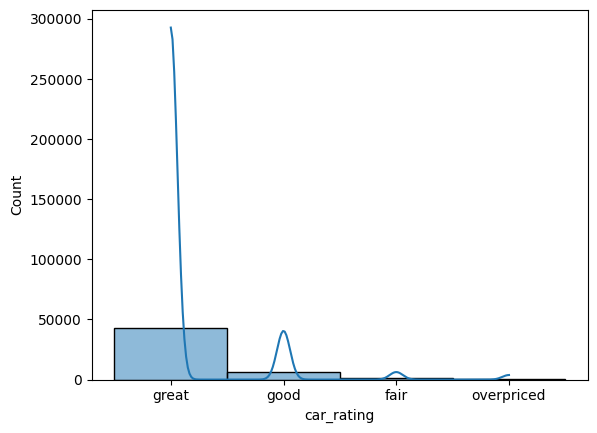

In [40]:
sns.histplot(df['car_rating'],kde=True,bins=50)

<Axes: xlabel='emi_starts_from', ylabel='Count'>

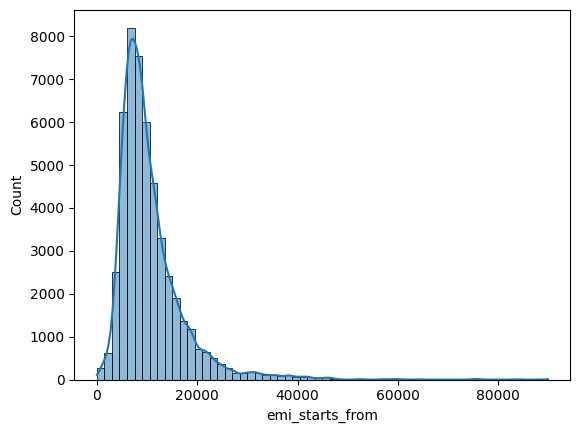

In [41]:
sns.histplot(df['emi_starts_from'],kde=True,bins=60)

<Axes: xlabel='booking_down_pymnt', ylabel='Count'>

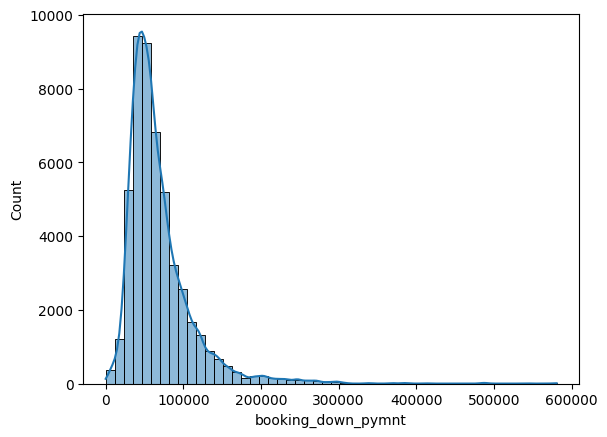

In [42]:
sns.histplot(df['booking_down_pymnt'],kde=True,bins=50)

<Axes: xlabel='year', ylabel='Count'>

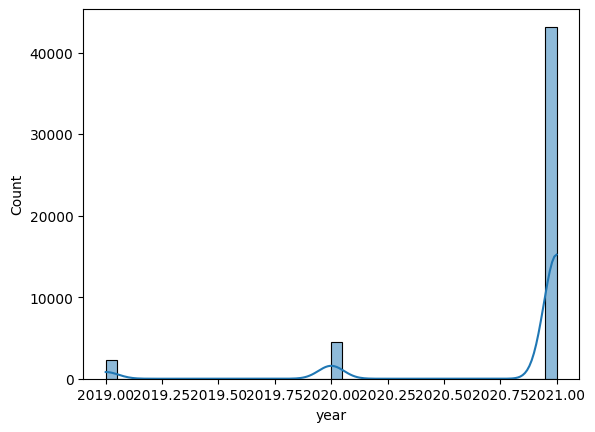

In [43]:
sns.histplot(df['year'],kde=True,bins=40)

<Axes: xlabel='month', ylabel='Count'>

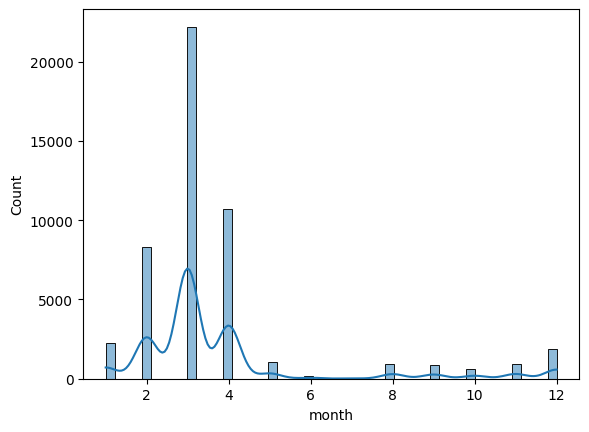

In [44]:
sns.histplot(df['month'],kde=True,bins=50)

In [45]:
cat_cols = [
    'fuel_type',
    'city',
    'body_type',
    'transmission',
    'assured_buy',
    'is_hot',
    'make',
    'model',
    'warranty_avail'
]

<Axes: xlabel='fuel_type', ylabel='count'>

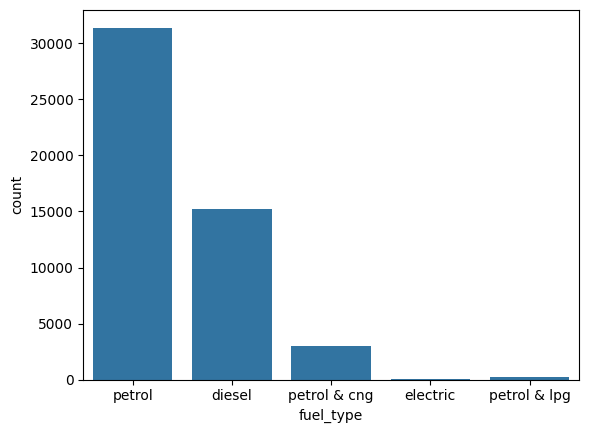

In [46]:
sns.countplot(x='fuel_type',data=df)

<Axes: xlabel='city', ylabel='count'>

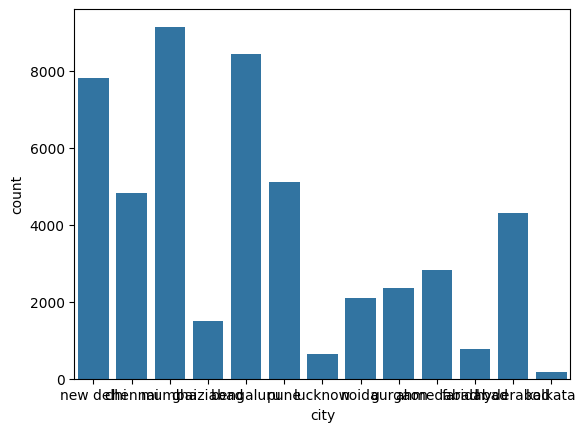

In [47]:
sns.countplot(x='city',data=df)

<Axes: xlabel='body_type', ylabel='count'>

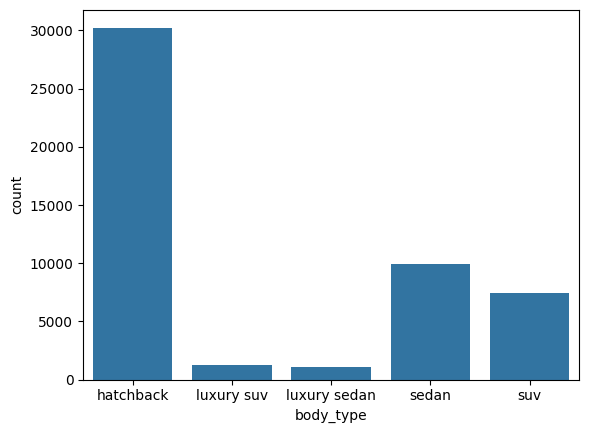

In [48]:
sns.countplot(x='body_type',data=df)

<Axes: xlabel='transmission', ylabel='count'>

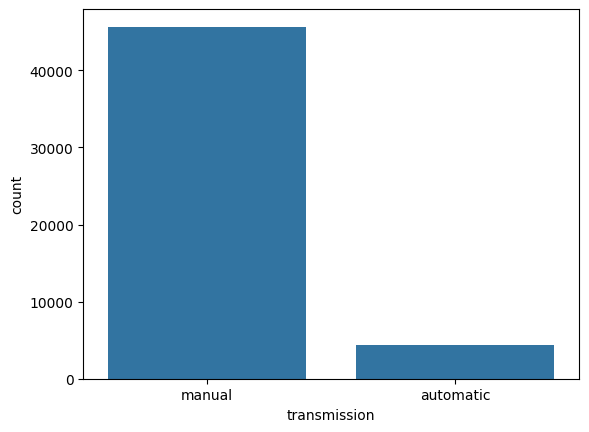

In [49]:
sns.countplot(x='transmission',data=df)

<Axes: xlabel='assured_buy', ylabel='count'>

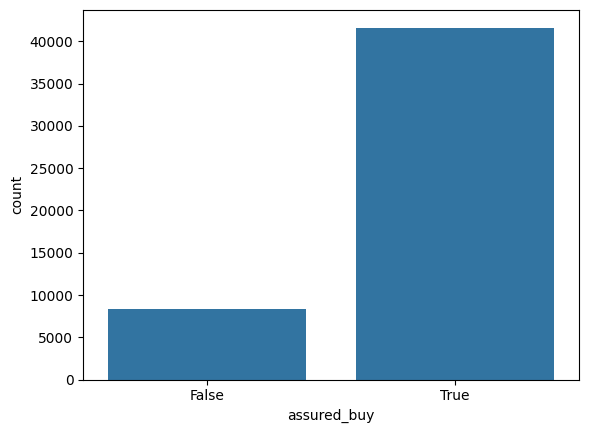

In [50]:
sns.countplot(x='assured_buy',data=df)

<Axes: xlabel='is_hot', ylabel='count'>

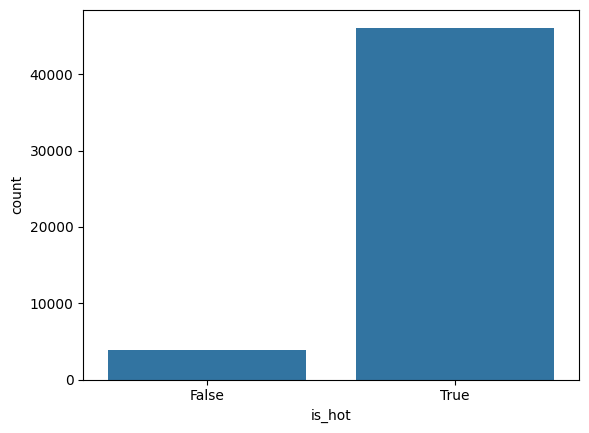

In [51]:
sns.countplot(x='is_hot',data=df)

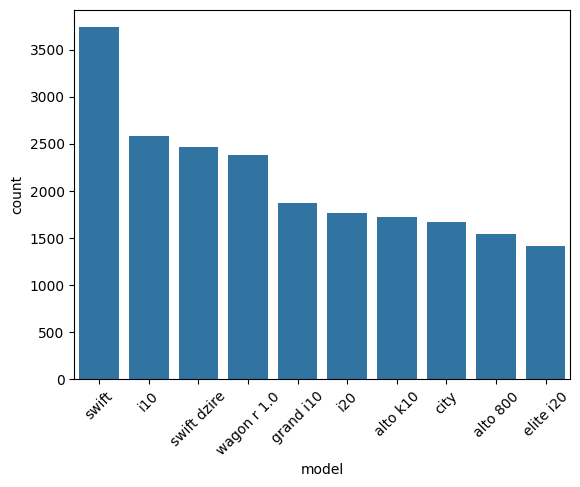

In [52]:
top_models = df['model'].value_counts().head(10).index
sns.countplot(x='model', data=df, order=top_models)
plt.xticks(rotation=45)
plt.show()

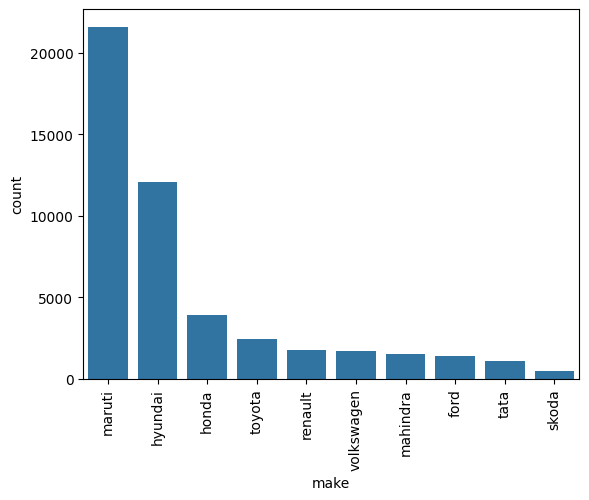

In [53]:
top_models = df['make'].value_counts().head(10).index
sns.countplot(x='make', data=df, order=top_models)
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='warranty_avail', ylabel='count'>

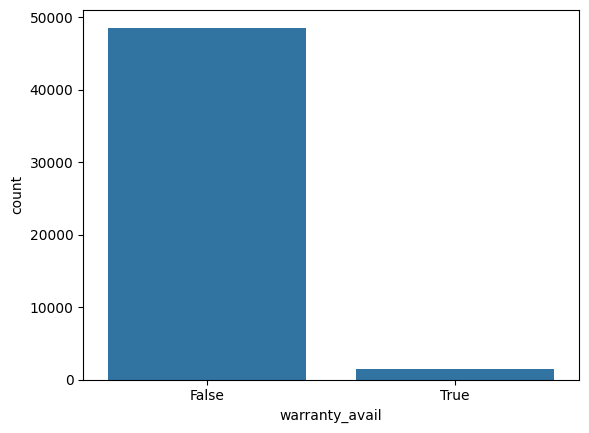

In [54]:
sns.countplot(x='warranty_avail',data=df)

<Axes: >

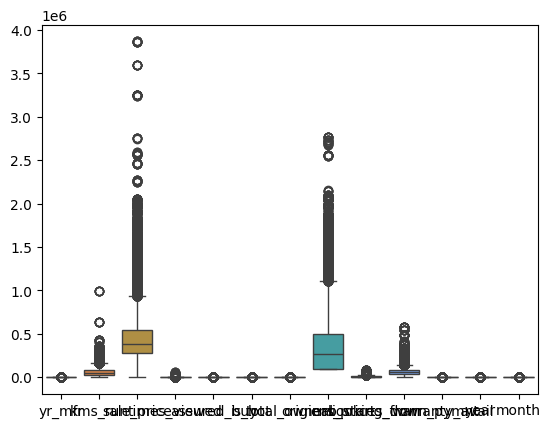

In [55]:
sns.boxplot(df)

In [56]:
df.dtypes

yr_mfr                float64
fuel_type                 str
kms_run               float64
sale_price            float64
city                      str
times_viewed          float64
body_type                 str
transmission              str
assured_buy              bool
is_hot                   bool
make                      str
model                     str
total_owners          float64
original_price        float64
car_rating                str
emi_starts_from       float64
booking_down_pymnt    float64
warranty_avail           bool
year                  float64
month                 float64
dtype: object

# BOXPLOT

In [57]:
num_cols = [
     'sale_price',
    'kms_run',
    'times_viewed',
    'total_owners',
    'emi_starts_from',
    'booking_down_pymnt',
    'year',
    'month',
    'yr_mfr' 
]

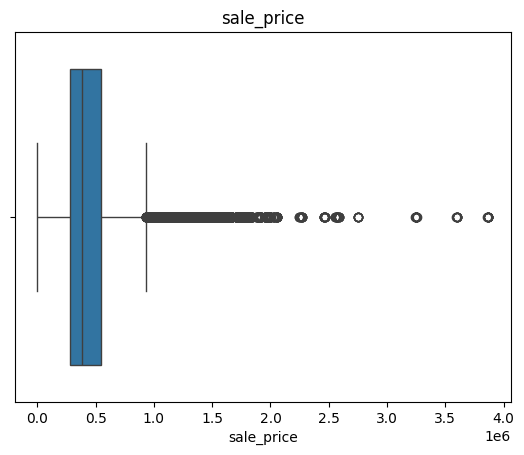

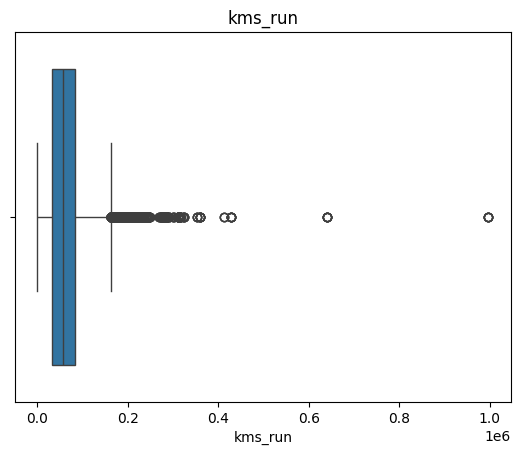

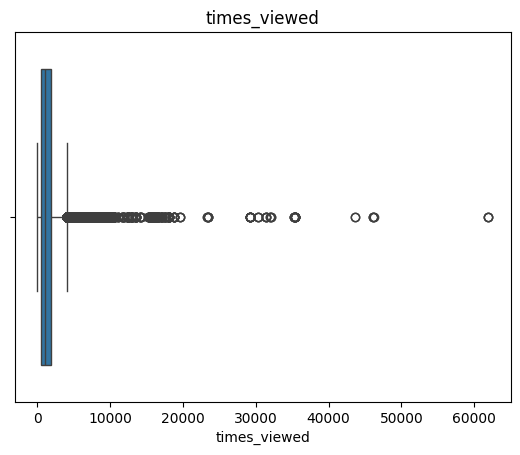

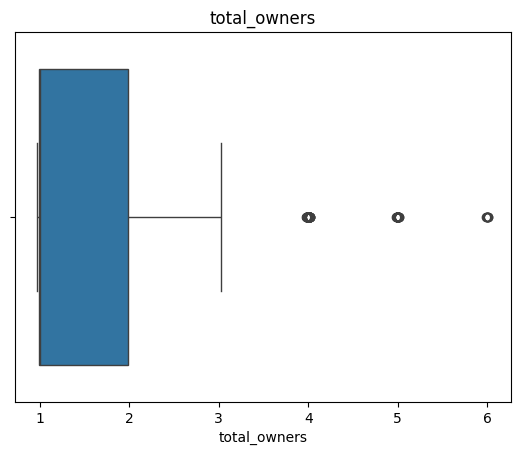

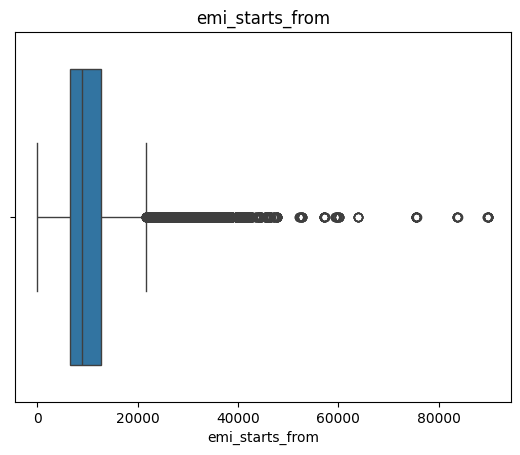

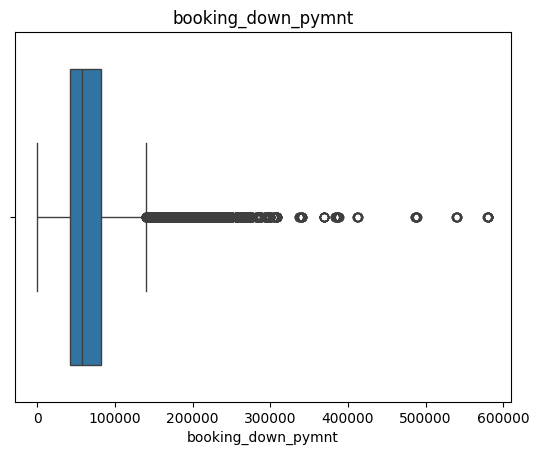

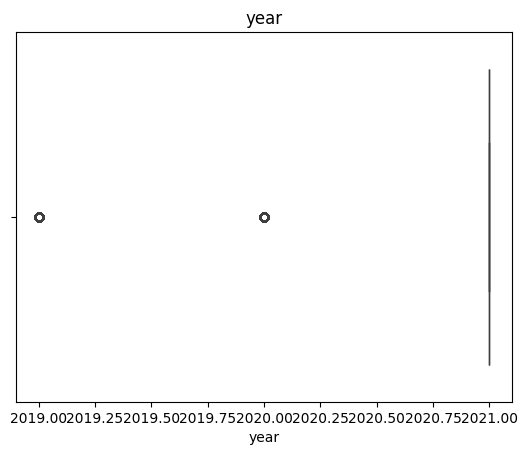

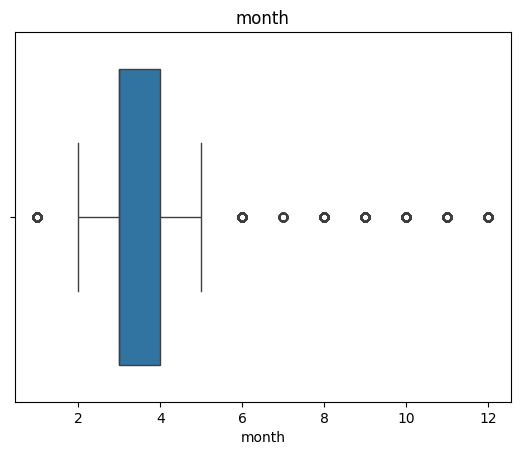

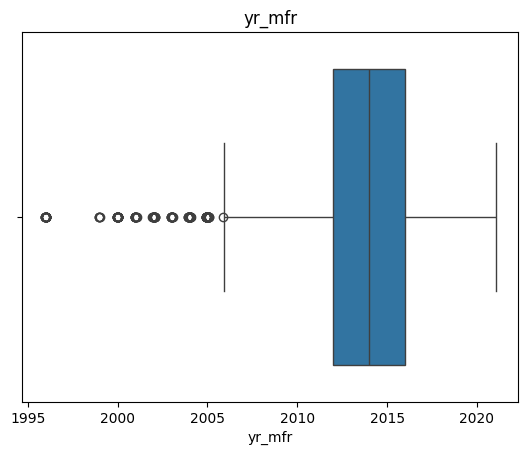

In [58]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [59]:
lst=['sale_price',
    'kms_run',
    'times_viewed',
    'total_owners',
    'emi_starts_from',
    'booking_down_pymnt',
    'year',
    'month',
    'yr_mfr']
for i in lst:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1

    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    df[i]=df[i].clip(lower,upper)

In [60]:
df

,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,assured_buy,is_hot,make,model,total_owners,original_price,car_rating,emi_starts_from,booking_down_pymnt,warranty_avail,year,month
0,2007.965992,petrol,37047.347056,109094.543920,new delhi,4001.822220,hatchback,manual,True,True,maruti,wagon r,0.995750,9.388607e+04,great,2515.757339,16957.752832,False,2021.0,2.0
1,2010.983001,petrol,80430.370425,258015.094503,chennai,374.907850,hatchback,manual,True,True,maruti,alto k10,0.998296,2.590545e+05,good,5885.909121,38560.428826,False,2021.0,3.0
2,2017.929802,diesel,5170.612874,933376.845118,new delhi,436.373962,hatchback,manual,False,False,ford,ecosport,1.001294,9.388607e+04,great,21713.414627,139978.354709,False,2021.0,5.0
3,2014.994807,diesel,82304.131491,933376.845118,mumbai,1251.603618,luxury suv,manual,True,True,mahindra,xuv500,0.999524,9.388607e+04,great,21713.414627,139978.354709,False,2021.0,3.0
4,2012.039742,diesel,91314.820341,933376.845118,ghaziabad,2717.175522,luxury sedan,automatic,True,True,audi,a6,2.004161,1.301035e+06,great,21713.414627,139978.354709,False,2021.0,5.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2016.024994,petrol,32351.859546,579514.320626,pune,1938.131285,hatchback,automatic,True,True,honda,jazz,0.990936,5.905758e+05,great,13466.686556,87477.194889,False,2021.0,2.0
49996,2015.974442,petrol,12818.128818,195587.854941,bengaluru,2486.416738,hatchback,manual,True,True,tata,nano,0.995204,9.388607e+04,great,4667.534538,29735.024034,False,2021.0,2.0
49997,2011.985577,diesel,77337.477188,275953.476899,ghaziabad,1101.631298,hatchback,manual,True,True,hyundai,i20,0.997773,3.365338e+05,great,6468.862726,41405.828381,False,2021.0,2.0
49998,2012.992009,petrol,45627.982766,277279.863864,gurgaon,2053.194216,hatchback,manual,True,True,honda,brio,1.002408,9.388607e+04,great,6450.594577,42061.173338,False,2021.0,4.0


In [61]:
df.drop(['model','original_price'], axis=1, inplace=True, errors='ignore')

In [62]:
l1=LabelEncoder()
l2=LabelEncoder()
l3=LabelEncoder()
df['assured_buy']=l1.fit_transform(df['assured_buy'])
df['is_hot']=l2.fit_transform(df['is_hot'])
df['warranty_avail']=l3.fit_transform(df['warranty_avail'])

In [63]:
top_city = df['city'].value_counts().head(10).index
df['city'] = df['city'].apply(lambda x: x if x in top_city else 'Other')

In [64]:
top_make = df['make'].value_counts().head(10).index
df['make'] = df['make'].apply(lambda x: x if x in top_make else 'Other')

In [65]:
df = pd.get_dummies(df, columns=[
    'fuel_type',
    'transmission',
    'body_type',
    'car_rating',
    'city',
    'make'
], drop_first=True,dtype=int)

In [66]:
df

,yr_mfr,kms_run,sale_price,times_viewed,assured_buy,is_hot,total_owners,emi_starts_from,booking_down_pymnt,warranty_avail,...,make_ford,make_honda,make_hyundai,make_mahindra,make_maruti,make_renault,make_skoda,make_tata,make_toyota,make_volkswagen
0,2007.965992,37047.347056,109094.543920,4001.822220,1,1,0.995750,2515.757339,16957.752832,0,...,0,0,0,0,1,0,0,0,0,0
1,2010.983001,80430.370425,258015.094503,374.907850,1,1,0.998296,5885.909121,38560.428826,0,...,0,0,0,0,1,0,0,0,0,0
2,2017.929802,5170.612874,933376.845118,436.373962,0,0,1.001294,21713.414627,139978.354709,0,...,1,0,0,0,0,0,0,0,0,0
3,2014.994807,82304.131491,933376.845118,1251.603618,1,1,0.999524,21713.414627,139978.354709,0,...,0,0,0,1,0,0,0,0,0,0
4,2012.039742,91314.820341,933376.845118,2717.175522,1,1,2.004161,21713.414627,139978.354709,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2016.024994,32351.859546,579514.320626,1938.131285,1,1,0.990936,13466.686556,87477.194889,0,...,0,1,0,0,0,0,0,0,0,0
49996,2015.974442,12818.128818,195587.854941,2486.416738,1,1,0.995204,4667.534538,29735.024034,0,...,0,0,0,0,0,0,0,1,0,0
49997,2011.985577,77337.477188,275953.476899,1101.631298,1,1,0.997773,6468.862726,41405.828381,0,...,0,0,1,0,0,0,0,0,0,0
49998,2012.992009,45627.982766,277279.863864,2053.194216,1,1,1.002408,6450.594577,42061.173338,0,...,0,1,0,0,0,0,0,0,0,0


In [67]:
df.drop(['emi_starts_from', 'booking_down_pymnt'], axis=1, inplace=True)

In [68]:
x=df.drop('sale_price',axis=1)
y=df['sale_price']

In [69]:
x

,yr_mfr,kms_run,times_viewed,assured_buy,is_hot,total_owners,warranty_avail,year,month,fuel_type_electric,...,make_ford,make_honda,make_hyundai,make_mahindra,make_maruti,make_renault,make_skoda,make_tata,make_toyota,make_volkswagen
0,2007.965992,37047.347056,4001.822220,1,1,0.995750,0,2021.0,2.0,0,...,0,0,0,0,1,0,0,0,0,0
1,2010.983001,80430.370425,374.907850,1,1,0.998296,0,2021.0,3.0,0,...,0,0,0,0,1,0,0,0,0,0
2,2017.929802,5170.612874,436.373962,0,0,1.001294,0,2021.0,5.0,0,...,1,0,0,0,0,0,0,0,0,0
3,2014.994807,82304.131491,1251.603618,1,1,0.999524,0,2021.0,3.0,0,...,0,0,0,1,0,0,0,0,0,0
4,2012.039742,91314.820341,2717.175522,1,1,2.004161,0,2021.0,5.5,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2016.024994,32351.859546,1938.131285,1,1,0.990936,0,2021.0,2.0,0,...,0,1,0,0,0,0,0,0,0,0
49996,2015.974442,12818.128818,2486.416738,1,1,0.995204,0,2021.0,2.0,0,...,0,0,0,0,0,0,0,1,0,0
49997,2011.985577,77337.477188,1101.631298,1,1,0.997773,0,2021.0,2.0,0,...,0,0,1,0,0,0,0,0,0,0
49998,2012.992009,45627.982766,2053.194216,1,1,1.002408,0,2021.0,4.0,0,...,0,1,0,0,0,0,0,0,0,0


In [70]:
y

0        109094.543920
1        258015.094503
2        933376.845118
3        933376.845118
4        933376.845118
             ...      
49995    579514.320626
49996    195587.854941
49997    275953.476899
49998    277279.863864
49999    518809.304743
Name: sale_price, Length: 49977, dtype: float64

In [71]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=40)

In [72]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

### LinearRegeression

In [73]:
lr = LinearRegression()

lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)       #prediction

print('R2:',r2_score(y_test,y_pred))     #R2 score
print("MAE",mean_absolute_error(y_test,y_pred))   #MAE(Mean absolute error)
print('RMSE',np.sqrt(mean_squared_error(y_test,y_pred))) #RMSE
print('Train:',lr.score(x_train,y_train))
print('Test:',lr.score(x_test,y_test))
print(lr.coef_)
print(lr.intercept_)

R2: 0.763818967227125
MAE 76599.34572728422
RMSE 102222.52711452718
Train: 0.7661240893601089
Test: 0.763818967227125
[ 1.12583347e+05 -1.28315321e+04 -1.35644061e+02 -2.08227796e+03
  3.46972400e+03 -7.50939269e+03 -2.59011591e+03  2.91038305e-11
  2.09123771e+03 -3.61950007e+03 -4.25474351e+04 -3.14145663e+04
 -8.01088244e+03 -2.04337297e+04  4.92768080e+04  6.49609764e+04
  3.08424351e+04  7.51594340e+04 -5.05971584e+03 -5.44758428e+03
  1.04715371e+03 -8.19748941e+02  3.57592099e+04  1.70270007e+04
 -1.44473986e+03  1.92409183e+03  1.87641251e+04  1.89846454e+04
 -1.81786454e+03 -6.39114051e+02  1.43016568e+04 -9.94108424e+03
  1.13521649e+04  1.53790277e+04 -1.43042565e+04 -8.92936712e+03
 -2.56050951e+04 -9.80257648e+03 -1.70225012e+04  1.08138847e+04
  6.36291041e+03]
435441.8627596143


In [74]:
#it shows the models row coefficient into readable format
coef_df = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': lr.coef_
})
print(coef_df.sort_values(by='Coefficient', ascending=False))

                   Feature   Coefficient
0                   yr_mfr  1.125833e+05
17           body_type_suv  7.515943e+04
15    body_type_luxury suv  6.496098e+04
14  body_type_luxury sedan  4.927681e+04
22          city_bengaluru  3.575921e+04
16         body_type_sedan  3.084244e+04
27             city_mumbai  1.898465e+04
26          city_hyderabad  1.876413e+04
23            city_chennai  1.702700e+04
33            make_hyundai  1.537903e+04
30               city_pune  1.430166e+04
32              make_honda  1.135216e+04
39             make_toyota  1.081388e+04
40         make_volkswagen  6.362910e+03
4                   is_hot  3.469724e+03
8                    month  2.091238e+03
25            city_gurgaon  1.924092e+03
20   car_rating_overpriced  1.047154e+03
7                     year  2.910383e-11
2             times_viewed -1.356441e+02
29              city_noida -6.391141e+02
21          city_ahmedabad -8.197489e+02
24          city_ghaziabad -1.444740e+03
28          city

### RandomForest